In [92]:
#Import necessary packages

import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import tqdm
from linearmodels import PanelOLS
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Exchangeable
import statsmodels.formula.api as smf

In [93]:
#Import necessary files

#Student datafile, data up to December 2025 
tip_clean = pd.read_csv(#reference your own working directory and TIP_clean file here,
    parse_dates=['CreatedDate','DoB', 'Interviewed Only Date', 'InterviewedDate','StartDate','EndDate'])

#Demographic datafile, data up to December 2024
tip_demos = pd.read_csv(#reference your own working direct and tip_cohort_demographics_rg.csv')

#Sentencing datafile, data up to December 2024
tip_sentencing = pd.read_csv(#reference your own working directory and convictions_matched_to_tip_final.csv', 
    parse_dates = ['DOB', 'GraduatedDate', 'InterviewedDate', 'StartDate','EndDate', 'DOF', 'DOS'])

#Arrests datafile, data up to December 2024
tip_arrests = pd.read_csv(#reference your own working directory and arrest_data.csv,
    parse_dates = ['CaseFiledDate', 'ArrestDate', 'DefendantDOB', 'OffenseDate','OffenseDispositionDate','CaseDispositionDate','InterviewedDate','Orientation Date', 'GraduatedDate', 'CreatedDate','StartDate','EndDate'])

#Earnings datafile, data up to December 2024
tip_earnings = pd.read_csv(#reference your own working directory and tip_cohort_uiearnings.csv')

#Deflation information to deflate earnings data
df_inflation = pd.read_csv(#reference your own working directory and inflation_data.csv')

#Social service usage data file
df_services = pd.read_csv(#reference your own working directory and tip_ss.csv')

#UI benefits usage data file
df_uibenefits = pd.read_csv(#reference your own working directory and tip_ui.csv')



C:\Users\sarah\AppData\Local\Temp\ipykernel_22376\886884731.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tip_arrests = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\arrest_data.csv', parse_dates = ['CaseFiledDate', 'ArrestDate', 'DefendantDOB', 'OffenseDate','OffenseDispositionDate','CaseDispositionDate','InterviewedDate','Orientation Date', 'GraduatedDate', 'CreatedDate','StartDate','EndDate'])
C:\Users\sarah\AppData\Local\Temp\ipykernel_22376\886884731.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tip_arrests = pd.read_csv(r'C:\Users\sarah\Documents\CMU\Spring 2026\Systems Synthesis\Data\Matching Data\arrest_data.csv', parse_dates = ['CaseFiledDate'

In [94]:
#Clean student datafile column names

all_tip_students = tip_clean.rename(columns={
    'participant_id' : 'tip_id',
    'DoB' : 'DOB',
    'Status' : 'tip_status',
})

#TIP typically does not include individuals who did not finish orientation as "non-graduates" in their own analyses. This is a stricter status
#Than has been used in previous years. For that reason, we are creating two status definitions: Strict_Status and Loose_Status
#To ensure we can reproduce last years results and to test whether we can get a usable sample if we use the more strict, new definition
def status_strict(row):
    ts = str(row['tip_status'])
    #If 'graduate' is in the tip status string, return "Graduated" as Status
    if "Graduate" in ts:
        return 'Graduated'
    #Else if 'DNF' is in the tip status string AND 'Orientation' is NOT in the tip status string, return "Non Graduated" as Status
    #TIP does not consider individuals who did not finish orientation to be participants, 
    elif ("DNF" in ts) & ("Orientation" not in ts):
        return 'Non Graduated'
    elif ("Leave" in ts) & ("Orientation" not in ts):
        return 'Non Graduated'
    #Assign all other rows a "None" for Status
    else:
        return 'None'
             
def status_loose(row):
    ts = str(row['tip_status'])
    #If 'graduate' is in the tip status string, return "Graduated" as Status
    if "Graduate" in ts:
        return 'Graduated'
    #Reverting back to 2025 approach: Less restriction on who is considered a non-graduate, we have added back in people who are "DNF-Orientation"
    elif ("DNF" in ts):
        return 'Non Graduated'
    elif ("Leave" in ts):
        return 'Non Graduated'
    #Assign all other rows a "None" for Status
    else:
        return 'None'

#Apply status functions to all rows in our TIP dataframe
all_tip_students['Strict_Status'] = all_tip_students.apply(status_strict, axis=1)
all_tip_students['Loose_Status'] = all_tip_students.apply(status_loose, axis=1)
all_tip_students.Strict_Status.value_counts()

#Apply tip start/end functions to all rows in our TIP dataframe
all_tip_students['year_TIP'] = all_tip_students['StartDate'].dt.year.values[0]
all_tip_students['year_end_TIP'] = all_tip_students['EndDate'].dt.year.values[0]

In [95]:
all_tip_students.Loose_Status.value_counts()

Loose_Status
None             932
Non Graduated    898
Graduated        893
Name: count, dtype: int64

In [96]:
all_tip_students['StartDate'].value_counts(dropna = False)

StartDate
NaT           888
2025-04-14     11
2025-02-10      9
2025-03-03      9
2025-06-30      9
             ... 
2015-06-15      1
2021-11-22      1
2015-06-17      1
2015-06-29      1
2026-01-05      1
Name: count, Length: 752, dtype: int64

In [97]:
all_tip_students['EndDate'].value_counts(dropna = False)

EndDate
NaT                          969
2025-04-11 00:00:00+00:00     21
2024-10-04 00:00:00+00:00     13
2025-10-02 00:00:00+00:00     12
2023-10-13 00:00:00+00:00     12
                            ... 
2017-11-17 00:00:00+00:00      1
2018-01-19 00:00:00+00:00      1
2017-12-28 00:00:00+00:00      1
2017-12-14 00:00:00+00:00      1
2026-01-07 00:00:00+00:00      1
Name: count, Length: 1071, dtype: int64

In [98]:
all_tip_students['DOB'].value_counts(dropna = False)

DOB
NaT           75
1996-07-01     4
1984-09-19     4
1987-03-18     3
1992-09-15     3
              ..
1990-08-05     1
1991-10-04     1
1991-05-04     1
1982-07-08     1
2006-08-24     1
Name: count, Length: 2329, dtype: int64

In [99]:
all_tip_students.columns

Index(['tip_id', 'CreatedDate', 'DOB', 'tip_status', 'Course', 'StartDate',
       'EndDate', 'InterviewedDate', 'Interviewed Only Date', 'DriversLicense',
       'EndDriversLicense', 'AccessBank', 'EndBank', 'EndComputer',
       'AccessComputer', 'AccessHealthInsurance', 'EndHealthInsurance',
       'AccessInternet', 'EndInternet', 'AccessResume', 'EndResume',
       'License To Thrive', 'Workforce Housing', 'SNAP Assistance',
       'Age_at_start', 'Strict_Status', 'Loose_Status', 'year_TIP',
       'year_end_TIP'],
      dtype='object')

In [100]:
#Put together our cleaned student data frame (which we will call df_student)

df_student = all_tip_students.copy()

#Clean date fields
date_cols = ['DOB', 'StartDate', 'EndDate', 'InterviewedDate', 'Interviewed Only Date']
for col in date_cols:
    if col in df_student.columns:
        df_student[col] = pd.to_datetime(df_student[col], errors = 'coerce')

##Add an indicator for cohort based on StartDate
cutoff = pd.Timestamp("2022-01-01")
df_student["cohort_2022"] = np.where(
    ##For any row that has a StartDate, if the StartDate is greater than or equal to our cutoff, assign post-2022 cohort (1)
    ##else assign pre-2022 cohort (0)
    df_student["StartDate"].notna(),
    np.where(df_student["StartDate"] >= cutoff, 1, 0),
    np.nan
)

#Ensure numeric
df_student["cohort_2022"] = pd.to_numeric(df_student["cohort_2022"], errors = "coerce")

In [101]:
df_student['whole_Age_at_start'] = df_student['Age_at_start'].round()

print(df_student['whole_Age_at_start'].value_counts(dropna=False))

whole_Age_at_start
NaN     919
20.0    121
19.0    115
23.0    115
24.0    111
27.0    104
25.0    103
28.0     96
26.0     94
22.0     88
29.0     87
21.0     86
32.0     69
31.0     69
30.0     63
18.0     52
33.0     49
37.0     42
36.0     40
35.0     38
34.0     36
39.0     34
41.0     27
40.0     26
38.0     23
43.0     17
42.0     17
45.0     16
44.0     15
47.0     10
46.0      7
48.0      6
52.0      4
49.0      4
55.0      3
51.0      3
0.0       3
59.0      2
58.0      2
54.0      2
50.0      1
16.0      1
65.0      1
53.0      1
17.0      1
Name: count, dtype: int64


In [102]:
#We have three individuals with nonsensical ages of 0
#1 sixteen-year-old and 1 seventeen-year-old, which could feasibly participate in TIP
#Drop anyone from our dataframe with suspect ages (under 16)
df_student = df_student[df_student['Age_at_start'] >= 16]

#Add age band based on age at start

def assign_age_band(age):
    if pd.isna(age):
        return np.nan
    elif age <= 24:
        return '<=24'
    elif 25 <= age <= 34:
        return '25-34'
    elif age >= 35:
        return '35+'
    else:
        return np.nan

df_student['age_band'] = df_student['Age_at_start'].apply(assign_age_band)

df_student.head()

,tip_id,CreatedDate,DOB,tip_status,Course,StartDate,EndDate,InterviewedDate,Interviewed Only Date,DriversLicense,...,Workforce Housing,SNAP Assistance,Age_at_start,Strict_Status,Loose_Status,year_TIP,year_end_TIP,cohort_2022,whole_Age_at_start,age_band
0,1,2018-07-11 00:00:00+00:00,1992-08-26,DNF: Dropped Out,Introduction to Masonry,2018-07-12,2018-08-01 00:00:00+00:00,NaT,NaT,No,...,NaN,NaN,25.840055,Non Graduated,Non Graduated,2018.0,2018.0,0.0,26.0,25-34
1,2,2018-07-11 00:00:00+00:00,1997-01-27,DNF: Asked to Leave,Introduction to Masonry,2018-07-12,NaT,NaT,NaT,No,...,NaN,NaN,21.424470,Non Graduated,Non Graduated,2018.0,2018.0,0.0,21.0,<=24
2,3,2018-07-11 00:00:00+00:00,1999-05-04,DNF: Asked to Leave,Introduction to Masonry,2018-07-23,NaT,NaT,NaT,NaN,...,NaN,NaN,19.193438,Non Graduated,Non Graduated,2018.0,2018.0,0.0,19.0,<=24
3,4,2018-07-12 00:00:00+00:00,1982-08-15,Graduated-Employed,Introduction to Masonry,2013-08-12,2013-10-16 00:00:00+00:00,NaT,NaT,NaN,...,NaN,NaN,30.950103,Graduated,Graduated,2018.0,2018.0,0.0,31.0,25-34
4,5,2018-07-12 00:00:00+00:00,1988-04-10,Graduated-Employed,Introduction to Masonry,2010-11-29,2011-02-04 00:00:00+00:00,NaT,NaT,NaN,...,NaN,NaN,22.605605,Graduated,Graduated,2018.0,2018.0,0.0,23.0,<=24


In [103]:
#Merge with demographics
#ensure tip_id is numeric for merge
tip_demos['tip_id'] = pd.to_numeric(tip_demos['tip_id'], errors='coerce')
df_student['tip_id'] = pd.to_numeric(df_student['tip_id'], errors='coerce')

df_student = df_student.merge(
    tip_demos,
    on = 'tip_id',
    how = 'left'
)

In [104]:
#Prepare sentencing data

#clean dates
tip_sentencing['DOB'] = pd.to_datetime(tip_sentencing['DOB'], errors='coerce').dt.tz_localize(None)
tip_sentencing['StartDate'] = pd.to_datetime(tip_sentencing['StartDate'], errors='coerce').dt.tz_localize(None)
tip_sentencing['EndDate'] = pd.to_datetime(tip_sentencing['EndDate'], errors='coerce').dt.tz_localize(None)
tip_sentencing['tip_id'] = pd.to_numeric(tip_sentencing['tip_id'], errors='coerce')

#define age at sentencing as date of sentencing minus date of birth divided by 365
tip_sentencing['age_at_sentencing'] = (
    (tip_sentencing['DOS'] - tip_sentencing['DOB'])).dt.days // 365

# merge student StartDate for consistent baseline cutoff
#concern is that the StartDate in the matched file may in some cases differ from the sentencing file
tip_sentencing = tip_sentencing.merge(
    df_student[['tip_id', 'StartDate']],
    on='tip_id',
    how='left',
    suffixes=('', '_student')
)

#set the StartDate from the student datafile (TIP_clean) as the preferred start date - overwrite others to this, if there are multiple
if 'StartDate_student' in tip_sentencing.columns:
    tip_sentencing['StartDate'] = tip_sentencing['StartDate_student'].combine_first(tip_sentencing['StartDate'])
    tip_sentencing = tip_sentencing.drop(columns=['StartDate_student'])

#create a dataframe of those with an offense record before TIP start
sent_before = tip_sentencing[
    #if row's DOS is not NA
    tip_sentencing['DOS'].notna() &
    #and the StartDate for the row is not NA
    tip_sentencing['StartDate'].notna() &
    #and the DOS is earlier than the TIP start date
    (tip_sentencing['DOS'] < tip_sentencing['StartDate'])
].copy()

#summarize sentences before start by tip_id 
sent_summary = sent_before.groupby('tip_id').agg(
    #number of sentences before start is the count of the number of DOS in the frame
    num_sentences_before_start=('DOS', 'count'),
    #any sentence before start is if length of DOS > 0 (this should be true for all)
    any_sentence_before_start=('DOS', lambda x: 1 if len(x) > 0 else 0),
    #identify the earliest offense age within the tip_id
    min_age_at_sentencing_before_start=('age_at_sentencing', 'min'),
    #identify the maximum OGS score within the tip_id
    max_ogs_before_start=('OGS', 'max'),
    #identify if the tip_id had a high OGS pre start (if length of vector of OGS scores > 5 is longer than 0 for the tip_id, 1, else 0)
    any_high_ogs_before_start=('OGS', lambda x: 1 if (x > 5).any() else 0)
).reset_index()

#diagnostics of sent_summary
#everyone should have a sentence before start
print(sent_summary['any_sentence_before_start'].value_counts(dropna = False))

#diagnostics of tip_sentencing
print(tip_sentencing["offense_indicator"].value_counts(dropna = False))

any_sentence_before_start
1    821
Name: count, dtype: int64
offense_indicator
1    7320
0    1502
Name: count, dtype: int64


In [105]:
#Prepare arrests data (similar process to conviction data above)

#ensure tip_id is numeric for merge
tip_arrests['tip_id'] = pd.to_numeric(tip_arrests['tip_id'], errors='coerce')

#merge arrest data with student data on tip_id
tip_arrests = tip_arrests.merge(
    df_student[['tip_id', 'DOB', 'StartDate']],
    on='tip_id',
    how='left',
    suffixes=('', '_student')
)

#Prefer StartDate from student data
if 'StartDate_student' in tip_arrests.columns:
    tip_arrests['StartDate'] = tip_arrests['StartDate_student'].combine_first(tip_arrests['StartDate'])
    tip_arrests = tip_arrests.drop(columns=['StartDate_student'])

#Establish age at arrest as Arrest Date - DOB divided by 365
tip_arrests['age_at_arrest'] = (
    (tip_arrests['ArrestDate'] - tip_arrests['DOB']).dt.days // 365
)

#Create an arrests before TIP dataframe
arrests_before = tip_arrests[
    #ArrestDate for row is not NA AND
    tip_arrests['ArrestDate'].notna() &
    #StartDate for row is not NA AND
    tip_arrests['StartDate'].notna() &
    #Arrest Date is earlier than Start Date
    (tip_arrests['ArrestDate'] < tip_arrests['StartDate'])
].copy()

#Summarize arrests before start by tip_id
arrest_summary = arrests_before.groupby('tip_id').agg(
    #count the number of arrests before start within the same ID based on number of ArrestDate's in the file
    num_arrests_before_start=('ArrestDate', 'count'),
    #Any arrest before start
    any_arrest_before_start=('ArrestDate', lambda x: 1 if len(x) > 0 else 0),
    #Minimum arrest age for the tip_id within the file
    min_age_at_arrest_before_start=('age_at_arrest', 'min')
).reset_index()

#add YearsSinceTIP to each arrest for later outcome analysis
tip_arrests['YearsSinceTIP'] = (tip_arrests['ArrestDate'] - tip_arrests['StartDate']).dt.days / 365

#diagnostic for arrest_summary
#everyone should have a 1 for any arrest before start

print(arrest_summary['any_arrest_before_start'].value_counts(dropna = False))


any_arrest_before_start
1    563
Name: count, dtype: int64


In [106]:
#Prepare earnings data

# process quarter to datetime
q_str = tip_earnings["quarter"].astype(str).str.strip()

tip_earnings["year"] = q_str.str[:4].astype(int)
tip_earnings["qnum"] = q_str.str[-1].astype(int)  # 1-4

# map to calendar quarter end month/day
# Q1 -> 03/31
# Q2 -> 06/30
# Q3 -> 09/30
# Q4 -> 12/31 

month_map = {1: 3, 2: 6, 3: 9, 4: 12}
day_map   = {1: 31, 2: 30, 3: 30, 4: 31}

tip_earnings["cal_end_year"] = tip_earnings["year"]
tip_earnings["cal_end_month"] = tip_earnings["qnum"].map(month_map)
tip_earnings["cal_end_day"] = tip_earnings["qnum"].map(day_map)

tip_earnings["year_quarter_dt"] = pd.to_datetime(
    dict(
        year=tip_earnings["cal_end_year"],
        month=tip_earnings["cal_end_month"],
        day=tip_earnings["cal_end_day"],
    ),
    errors="coerce",
)

tip_earnings["year_month"] = tip_earnings["year_quarter_dt"].dt.to_period("M")
tip_earnings.drop(columns=["Unnamed: 0", "qnum", "cal_end_year", "cal_end_month", "cal_end_day"], errors="ignore", inplace=True)

In [107]:
tip_earnings['earnings'].describe()

count    73276.000000
mean      2050.402847
std       3631.671300
min          0.000000
25%          0.000000
50%        202.000000
75%       2610.250000
max      61087.000000
Name: earnings, dtype: float64

In [108]:
df_inflation.columns

Index(['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec', 'HALF1', 'HALF2'],
      dtype='object')

In [109]:
#Adjust earnings data for inflation (deflate the data)
df_inflation.drop(columns=['HALF1', 'HALF2'], inplace=True)
df_inflation = df_inflation.melt(id_vars='Year', var_name='Month', value_name='CPI')

month_map = {'Jan':'01','Feb':'02','Mar':'03','Apr':'04','May':'05','Jun':'06',
             'Jul':'07','Aug':'08','Sep':'09','Oct':'10','Nov':'11','Dec':'12'}
df_inflation["year_month"] = (
    df_inflation["Year"].astype(str) + "-" + df_inflation["Month"].map(month_map)
)
# sort by date to ensure that the latest CPI value is at the end of the DataFrame
df_inflation = df_inflation.sort_values("year_month").reset_index(drop=True)
latest_cpi = df_inflation.loc[df_inflation["year_month"] == "2025-12", "CPI"].iloc[0]

tip_earnings["year_month"] = tip_earnings["year_month"].astype(str)

cpi_map = df_inflation.drop_duplicates("year_month").set_index("year_month")["CPI"]
tip_earnings["CPI"] = tip_earnings["year_month"].map(cpi_map)

#deflate earnings to adjusted_earnings
tip_earnings["adjusted_earnings"] = tip_earnings["earnings"] * (latest_cpi / tip_earnings["CPI"])

In [110]:
#diagnostic check: do any rows have an adjusted earnings of 0?
tip_earnings['adjusted_earnings'].min()

0.0

In [111]:
#diagnostic check: how many rows have an adjusted earnings of 0?
zero_earnings = tip_earnings[tip_earnings['adjusted_earnings'] == 0]
len(zero_earnings)

#Note: We will need to add +$1 when logging earnings to ensure that we don't drop our 0's

32404

In [112]:
tip_earnings.head()

,tip_id,quarter,employer_legal_name,earnings,naics_code,naics_sector_2017,naics_subsector_2017,naics_industry_2017,naics_sector_2022,naics_subsector_2022,naics_industry_2022,year,year_quarter_dt,year_month,CPI,adjusted_earnings
0,655,20182,LEHIGH VALLEY RESTAURANT GROUP INC,1434,722511.0,Accommodation and food services,Food services and drinking places,Full-Service Restaurants,Accommodation and Food Services,Food Services and Drinking Places,Full-Service Restaurants,2018,2018-06-30,2018-06,251.989,1844.102068
1,556,20174,COST COMPANY,3147,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12,246.524,4136.708548
2,556,20174,FRANCO,4654,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12,246.524,6117.649056
3,556,20181,COST COMPANY,1908,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03,249.554,2477.600167
4,556,20181,FRANCO,7165,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03,249.554,9303.985951


In [113]:
#Create variables of earnings 1 year and 2 years pre-TIP for later use in our matching algorithm

#Merge tip_earnings data with student data
tip_earnings = pd.merge(
    tip_earnings,
    df_student[['tip_id', 'StartDate']].drop_duplicates(),
    on='tip_id',
    how = 'left'
)

tip_earnings.head()

,tip_id,quarter,employer_legal_name,earnings,naics_code,naics_sector_2017,naics_subsector_2017,naics_industry_2017,naics_sector_2022,naics_subsector_2022,naics_industry_2022,year,year_quarter_dt,year_month,CPI,adjusted_earnings,StartDate
0,655,20182,LEHIGH VALLEY RESTAURANT GROUP INC,1434,722511.0,Accommodation and food services,Food services and drinking places,Full-Service Restaurants,Accommodation and Food Services,Food Services and Drinking Places,Full-Service Restaurants,2018,2018-06-30,2018-06,251.989,1844.102068,2021-06-03
1,556,20174,COST COMPANY,3147,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12,246.524,4136.708548,2017-03-29
2,556,20174,FRANCO,4654,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2017,2017-12-31,2017-12,246.524,6117.649056,2017-03-29
3,556,20181,COST COMPANY,1908,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03,249.554,2477.600167,2017-03-29
4,556,20181,FRANCO,7165,238142.0,Construction,Specialty trade contractors,Masonry Contractors - Nonresidential,Construction,Specialty Trade Contractors,Masonry Contractors (non-residential),2018,2018-03-31,2018-03,249.554,9303.985951,2017-03-29


In [114]:
# keep only rows with non-missing earnings and DO NOT drop zeros
#tip_earnings = tip_earnings.dropna(subset=['earnings', 'StartDate']).copy()

#calculate time distance relative to TIP start
tip_earnings['days_from_start'] = (
    (tip_earnings['year_quarter_dt'] - tip_earnings['StartDate']).dt.days
)

#aggregate 1-year pre-TIP earnings (-1 to -365)
earnings_1yr_pre = (
    tip_earnings[tip_earnings['days_from_start'].between(-365,-1)]
    .groupby('tip_id')['adjusted_earnings']
    .sum()
    .reset_index()
    .rename(columns={'adjusted_earnings': 'earnings_1yr_preTIP'})
)

#aggregate 2-year pre-TIP earnings (-1 to -730) 
earnings_2yr_pre = (
    tip_earnings[tip_earnings['days_from_start'].between(-730,-1)]
    .groupby('tip_id')['adjusted_earnings']
    .sum()
    .reset_index()
    .rename(columns={'adjusted_earnings': 'earnings_2yr_preTIP'})
)

earnings_2yr_pre.head()

,tip_id,earnings_2yr_preTIP
0,1,410.102835
1,2,46725.416864
2,28,53665.394917
3,29,40736.695066
4,210,11651.982370


In [115]:
#Summarize employment immediately pre-TIP using earnings data (just checks for existence of any earnings in the year immediately prior to TIP
job_right_before = (
    tip_earnings[tip_earnings['days_from_start'].between(-183, -1)] 
    .groupby('tip_id')['adjusted_earnings']
    .apply(lambda x: 1 if (x > 0).any() else 0)
    .reset_index(name='job_right_before_tip')
)


In [116]:
#add YearsSinceTIP to long df for later outcome analysis
tip_earnings['YearsSinceTIP'] = (tip_earnings['year_quarter_dt'] - tip_earnings['StartDate']).dt.days / 365

In [117]:
#clean UI and social service data for later diagnostic use

#rename columns
df_uibenefits = df_uibenefits.rename(columns={"TIP_ID": "tip_id"})
df_uibenefits["quarter"] = pd.to_numeric(df_uibenefits["REQUEST_PERIOD"], errors="coerce")

#Extract the quarter number from the five digit request date
df_uibenefits["q_num"] = (df_uibenefits["quarter"] % 10).astype("Int64")
#Extract the year from the five digit request date
df_uibenefits["year"] = (df_uibenefits["quarter"] // 10).astype("Int64")

#Add a dummy variable signifying whether they received benefits that period
df_uibenefits["ui_dummy"] = (~df_uibenefits["UC_BENEFIT"].isna()).astype(int)

#Annualize the data: if any quarter in that year has ui_dummy==1 -> received UI that year
df_ui_annual = (
    df_uibenefits.groupby(["tip_id", "year"], as_index=False)["ui_dummy"]
    .max()
)

#merge service data with annual UI data on tip_id and year, preserving all rows across both
df_services = df_services.merge(
    df_ui_annual,   
    on=["tip_id", "year"],
    how="outer"
)

#create an indicator for whether the tip_id showed up as using an Allegheny County social service within that year OR had UI benefits that year
#by summing values of all binary service columns and UI dummy
df_services['sum'] = df_services.iloc[:, 4:29].sum(axis=1)
df_services.head()

,Unnamed: 0,tip_id,year,aging,drug_alcohol,mental_health,cyf_child,cyf_parent,family_support_center,early_childhood,...,section8_housing,courts,medicaid,jail,snap,tanf,ssi,ccdf,ui_dummy,sum
0,18669.0,1,2010,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0
1,18670.0,1,2011,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,NaN,3.0
2,18671.0,1,2012,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,NaN,4.0
3,18672.0,1,2013,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,NaN,4.0
4,18673.0,1,2014,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,NaN,4.0


In [118]:
#diagnostic check: UI dummies
print(df_services['ui_dummy'].value_counts(dropna = False))

ui_dummy
0.0    15204
NaN    12379
1.0     1225
Name: count, dtype: int64


In [119]:
#diagnostic check: does every row in our combined data frame already indicate that the tip_id received something in Allegheny County that year? 
(df_services['sum'] > 0).all()

np.False_

In [120]:
#Create dataframe we can use as an indicator of likely still living in Allegheny County, even if they do not have earnings/employment data for that year
ac_ss_records = df_services.copy()

#only include tip_id's that showed some Allegheny County service receipt (sum of binary service usage indicators and UI indicator >= 1)
ac_ss_records = ac_ss_records[ac_ss_records["sum"] >= 1]

In [121]:
#merge earnings dataframe with our Allegheny County records list
ac_records = ac_ss_records.merge(
    tip_earnings[["tip_id", "year", 'adjusted_earnings']],
    on=["tip_id", "year"],
    how="outer"
)

ac_records.head()

,Unnamed: 0,tip_id,year,aging,drug_alcohol,mental_health,cyf_child,cyf_parent,family_support_center,early_childhood,...,courts,medicaid,jail,snap,tanf,ssi,ccdf,ui_dummy,sum,adjusted_earnings
0,18669.0,1,2010,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,NaN
1,18670.0,1,2011,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,NaN,3.0,NaN
2,18671.0,1,2012,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,NaN,4.0,NaN
3,18672.0,1,2013,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,NaN,4.0,NaN
4,18673.0,1,2014,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,NaN,4.0,NaN


In [122]:
#Check merge - we will likely see some rows that now have NA for sum
print(ac_records['sum'].value_counts(dropna = False))

sum
2.0     17736
3.0     17063
1.0     15650
4.0     12190
5.0      7847
6.0      4944
NaN      4867
7.0      2888
8.0      1421
9.0       712
10.0      219
11.0       74
12.0       32
14.0        7
13.0        4
Name: count, dtype: int64


In [123]:
#assign missing 'sums' as 0 (didn't show up as using social service or UI data for the year, did show up in earnings records)
ac_records['sum'] = ac_records['sum'].fillna(0)
print(ac_records['sum'].value_counts(dropna = False))

sum
2.0     17736
3.0     17063
1.0     15650
4.0     12190
5.0      7847
6.0      4944
0.0      4867
7.0      2888
8.0      1421
9.0       712
10.0      219
11.0       74
12.0       32
14.0        7
13.0        4
Name: count, dtype: int64


In [124]:
#diagnostics check on those with missing earnings records
missing_earnings = ac_records[ac_records['adjusted_earnings'].isna()]

#if someone has a sum that is > 0, they showed up as using a social service or UI that year. They probably don't have an earnings record
#because they truly weren't earnings, as we do see them show up in our other Allegheny County data
likely_true_zero = missing_earnings[missing_earnings['sum'] > 0]

#if someone is both missing earnings data and has a sum == 0, means they may be out of sample - they don't show up in any data in 
#Allegheny County for that year
maybe_out_of_sample = missing_earnings[missing_earnings['sum'] == 0]

print(len(likely_true_zero))
print(len(maybe_out_of_sample))

12378
0


In [125]:
#create earnings and employment outcomes
df_student['EndDate'] = pd.to_datetime(df_student['EndDate'], errors='coerce').dt.tz_localize(None)

#Merge EndDate into tip_earnings
tip_earnings = tip_earnings.merge(
    df_student[['tip_id', 'EndDate']].drop_duplicates(),
    on='tip_id',
    how='left'
)


#Calculate days relative to TIP END date
tip_earnings['days_from_end'] = (
    (tip_earnings['year_quarter_dt'] - tip_earnings['EndDate']).dt.days
)

#Filter to 18-month post-TIP window (0 to +547 days)
post_18mo = tip_earnings[tip_earnings['days_from_end'].between(1, 547)].copy()

earnings_18mo_post = (
    post_18mo
    .groupby('tip_id')['adjusted_earnings']
    .sum()
    .reset_index()
    .rename(columns={'adjusted_earnings': 'earnings_18mo_postTIP'})
)

any_employed_18mo = (
    post_18mo
    .groupby('tip_id')['adjusted_earnings']
    .apply(lambda x: 1 if (x > 0).any() else 0)
    .reset_index(name='any_employed_18mo_postTIP')
)

full_employed_18mo = (
    post_18mo
    .groupby('tip_id')['adjusted_earnings']
    .apply(lambda x: 1 if (x > 0).all() else 0)
    .reset_index(name='full_employed_18mo_postTIP')
)

In [126]:
#combine with summary data for matching
all_tip_data = pd.merge(
    df_student,
    sent_summary, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    arrest_summary, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    earnings_1yr_pre, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    earnings_2yr_pre, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    job_right_before, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    earnings_18mo_post,
    on='tip_id',
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    any_employed_18mo,
    on='tip_id',
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    full_employed_18mo,
    on='tip_id',
    how='left'
)


In [127]:
all_tip_data.columns

Index(['tip_id', 'CreatedDate', 'DOB', 'tip_status', 'Course', 'StartDate',
       'EndDate', 'InterviewedDate', 'Interviewed Only Date', 'DriversLicense',
       'EndDriversLicense', 'AccessBank', 'EndBank', 'EndComputer',
       'AccessComputer', 'AccessHealthInsurance', 'EndHealthInsurance',
       'AccessInternet', 'EndInternet', 'AccessResume', 'EndResume',
       'License To Thrive', 'Workforce Housing', 'SNAP Assistance',
       'Age_at_start', 'Strict_Status', 'Loose_Status', 'year_TIP',
       'year_end_TIP', 'cohort_2022', 'whole_Age_at_start', 'age_band',
       'Unnamed: 0', 'year_of_birth', 'year_of_death', 'census_tract',
       'gender', 'race', 'num_sentences_before_start',
       'any_sentence_before_start', 'min_age_at_sentencing_before_start',
       'max_ogs_before_start', 'any_high_ogs_before_start',
       'num_arrests_before_start', 'any_arrest_before_start',
       'min_age_at_arrest_before_start', 'earnings_1yr_preTIP',
       'earnings_2yr_preTIP', 'job_right_

In [128]:
tip_fill_zero_cols = [
    'num_sentences_before_start',
    'any_sentence_before_start',
    'max_ogs_before_start',
    'any_high_ogs_before_start',
    'num_arrests_before_start',
    'any_arrest_before_start',
    'earnings_1yr_preTIP',
    'earnings_2yr_preTIP',
    'job_right_before_tip',
    'job_2yr_before_tip',
    'earnings_18mo_postTIP',
    'any_employed_18mo_postTIP',
    'full_employed_18mo_postTIP'
]

for col in tip_fill_zero_cols:
    if col in all_tip_data.columns:
        all_tip_data[col] = all_tip_data[col].fillna(0)


In [129]:
#log earnings for analysis

all_tip_data['log_earnings_1yr_preTIP'] = np.log(all_tip_data['earnings_1yr_preTIP'] + 1)
all_tip_data['log_earnings_2yr_preTIP'] = np.log(all_tip_data['earnings_2yr_preTIP'] + 1)
all_tip_data['log_earnings_18mo_postTIP'] = np.log(all_tip_data['earnings_18mo_postTIP']+1)

print("all_tip_data shape:", all_tip_data.shape)
print("\nTIP missingness summary:")
print(
    all_tip_data[
        [
            'tip_id', 'DOB', 'StartDate', 'EndDate','Loose_Status','Strict_Status', 'cohort_2022',
            'Age_at_start', 'age_band', 'gender', 'race', 'census_tract',
            'num_sentences_before_start', 'any_sentence_before_start',
            'max_ogs_before_start', 'any_high_ogs_before_start',
            'num_arrests_before_start', 'any_arrest_before_start',
            'earnings_1yr_preTIP', 'earnings_2yr_preTIP',
            'job_right_before_tip', 'log_earnings_18mo_postTIP', 'full_employed_18mo_postTIP', 'any_employed_18mo_postTIP'
        ]
    ].isna().sum()
)

all_tip_data shape: (1801, 55)

TIP missingness summary:
tip_id                          0
DOB                             0
StartDate                       0
EndDate                        82
Loose_Status                    0
Strict_Status                   0
cohort_2022                     0
Age_at_start                    0
age_band                      133
gender                        317
race                          326
census_tract                  326
num_sentences_before_start      0
any_sentence_before_start       0
max_ogs_before_start            0
any_high_ogs_before_start       0
num_arrests_before_start        0
any_arrest_before_start         0
earnings_1yr_preTIP             0
earnings_2yr_preTIP             0
job_right_before_tip            0
log_earnings_18mo_postTIP       0
full_employed_18mo_postTIP      0
any_employed_18mo_postTIP       0
dtype: int64


In [130]:
#Create a study cutoff indicator
all_tip_data['StartDate'] = pd.to_datetime(all_tip_data['StartDate'], errors='coerce').dt.tz_localize(None)
all_tip_data['EndDate'] = pd.to_datetime(all_tip_data['EndDate'], errors='coerce').dt.tz_localize(None)

#Create indicator for whether an individual falls within the date ranges for our data sources
all_tip_data['within_time_window'] = (
    (all_tip_data['StartDate'] >= pd.Timestamp('2018-01-01')) &
    (all_tip_data['EndDate'] <= pd.Timestamp('2024-09-30'))
).fillna(False).astype(int)

In [131]:
# Clean demographic display values
all_tip_data['race'] = all_tip_data['race'].fillna('Unknown').replace(0, 'Unknown')
all_tip_data['gender'] = all_tip_data['gender'].fillna('Unknown').replace(0, 'Unknown')

all_tip_data['census_tract'] = all_tip_data['census_tract'].where(
    all_tip_data['census_tract'].notna(),
    'Unknown'
)

#Create a graduate/nongrad only file
grad_non_grad = all_tip_data.copy()

grad_non_grad_strict = grad_non_grad[
    grad_non_grad['Strict_Status'].isin(['Graduated', 'Non Graduated'])
].copy()

grad_non_grad_loose = grad_non_grad[
    grad_non_grad['Loose_Status'].isin(['Graduated', 'Non Graduated'])
    ].copy()

#Define treatment
grad_non_grad_strict['treatment'] = np.where(
    grad_non_grad_strict['Strict_Status'] == 'Graduated',
    1,
    0
)

grad_non_grad_loose['treatment'] = np.where(
    grad_non_grad_loose['Loose_Status'] == 'Graduated',
    1,
    0
)

In [132]:
#computes binary offense outcome post-TIP
def offense_outcome(row):
    tip_id = row['tip_id']
    #for each tip_id, filter tip_sentencing such that it only includes rows where
    return tip_sentencing[
        #tip_id in tip_sentencing matches the tip_id in the student dataframe
        (tip_sentencing['tip_id'] == tip_id) &
        #the offense indicator associated with that row is 1 (there is an offense)
        #(We must include this because our tip_sentencing data frame includes TIP individuals without offenses as well)
        (tip_sentencing['offense_indicator'] == 1) &
        #years since TIP of that offense is between 0 and 1.5
        (tip_sentencing['YearsSinceTIP'] > 0) &
        (tip_sentencing['YearsSinceTIP'] < 1.5)
        #if length of resulting data frame is > 0, offense outcome = 1
    ].shape[0] > 0

#computes binary arrest outcome post-TIP
def arrest_outcome(row):
    tip_id = row['tip_id']
    #for each tip_id, filter tip_arrests such that it only includes rows where
    return tip_arrests[
        #tip_id matches the id in the student data frame
        (tip_arrests['tip_id'] == tip_id) &
        #Years since TIP associated with the arrest record is between 0 and 1.5
        (tip_arrests['YearsSinceTIP'] > 0) &
        (tip_arrests['YearsSinceTIP'] < 1.5)
        #if length of resulting data frame is > 0, outcome = 1
    ].shape[0] > 0



#apply these functions across the grad_non_grad data frame
grad_non_grad_loose['offense_outcome'] = grad_non_grad_loose.apply(offense_outcome, axis=1).astype(int)
grad_non_grad_strict['offense_outcome'] = grad_non_grad_strict.apply(offense_outcome, axis=1).astype(int)
grad_non_grad_loose['arrest_outcome'] = grad_non_grad_loose.apply(arrest_outcome, axis=1).astype(int)
grad_non_grad_strict['arrest_outcome'] = grad_non_grad_strict.apply(arrest_outcome, axis=1).astype(int)

grad_non_grad_loose.head()

,tip_id,CreatedDate,DOB,tip_status,Course,StartDate,EndDate,InterviewedDate,Interviewed Only Date,DriversLicense,...,earnings_18mo_postTIP,any_employed_18mo_postTIP,full_employed_18mo_postTIP,log_earnings_1yr_preTIP,log_earnings_2yr_preTIP,log_earnings_18mo_postTIP,within_time_window,treatment,offense_outcome,arrest_outcome
0,1,2018-07-11 00:00:00+00:00,1992-08-26,DNF: Dropped Out,Introduction to Masonry,2018-07-12,2018-08-01,NaT,NaT,No,...,29140.184795,1.0,0.0,0.000000,6.018843,10.279908,1,0,0,0
1,2,2018-07-11 00:00:00+00:00,1997-01-27,DNF: Asked to Leave,Introduction to Masonry,2018-07-12,NaT,NaT,NaT,No,...,0.000000,0.0,0.0,10.562991,10.752065,0.000000,0,0,0,0
2,3,2018-07-11 00:00:00+00:00,1999-05-04,DNF: Asked to Leave,Introduction to Masonry,2018-07-23,NaT,NaT,NaT,NaN,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0,0,0,0
3,4,2018-07-12 00:00:00+00:00,1982-08-15,Graduated-Employed,Introduction to Masonry,2013-08-12,2013-10-16,NaT,NaT,NaN,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0,1,0,0
4,5,2018-07-12 00:00:00+00:00,1988-04-10,Graduated-Employed,Introduction to Masonry,2010-11-29,2011-02-04,NaT,NaT,NaN,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0,1,0,0


In [133]:
#check for NAs
grad_non_grad_loose[['any_employed_18mo_postTIP', 'full_employed_18mo_postTIP','earnings_18mo_postTIP', 'offense_outcome', 'arrest_outcome']].isna().sum()

any_employed_18mo_postTIP     0
full_employed_18mo_postTIP    0
earnings_18mo_postTIP         0
offense_outcome               0
arrest_outcome                0
dtype: int64

In [134]:
#loose data frame check

print("grad_non_grad_loose shape:", grad_non_grad_loose.shape)
print("\nStatus counts:")
print(grad_non_grad_loose['Loose_Status'].value_counts(dropna=False))

print("\nTreatment counts:")
print(grad_non_grad_loose['treatment'].value_counts(dropna=False))

print("\nTreatment within time window:")
print(pd.crosstab(grad_non_grad_loose['within_time_window'], grad_non_grad_loose['treatment'], margins=True))

print("\nCohort counts by treatment:")
print(pd.crosstab(grad_non_grad_loose['cohort_2022'], grad_non_grad_loose['treatment'], margins=True))

print("\nAge band counts by treatment:")
print(pd.crosstab(grad_non_grad_loose['age_band'], grad_non_grad_loose['treatment'], margins=True))

print("\nOutcome means by treatment:")
print(
    grad_non_grad_loose.groupby('treatment')[
        [
            'full_employed_18mo_postTIP',
            'any_employed_18mo_postTIP',
            'earnings_18mo_postTIP',
            'offense_outcome',
            'arrest_outcome'
        ]
    ].mean(numeric_only=True)
)

grad_non_grad_loose shape: (1753, 59)

Status counts:
Loose_Status
Non Graduated    877
Graduated        876
Name: count, dtype: int64

Treatment counts:
treatment
0    877
1    876
Name: count, dtype: int64

Treatment within time window:
treatment             0    1   All
within_time_window                
0                   410  412   822
1                   467  464   931
All                 877  876  1753

Cohort counts by treatment:
treatment      0    1   All
cohort_2022                
0.0          530  509  1039
1.0          347  367   714
All          877  876  1753

Age band counts by treatment:
treatment    0    1   All
age_band                 
25-34      322  362   684
35+        132  180   312
<=24       364  261   625
All        818  803  1621

Outcome means by treatment:
           full_employed_18mo_postTIP  any_employed_18mo_postTIP  \
treatment                                                          
0                            0.167617                   0.514253 

In [135]:
#strict data frame check

print("grad_non_grad_strict shape:", grad_non_grad_loose.shape)
print("\nStatus counts:")
print(grad_non_grad_strict['Strict_Status'].value_counts(dropna=False))

print("\nTreatment counts:")
print(grad_non_grad_strict['treatment'].value_counts(dropna=False))

print("\nTreatment within time window:")
print(pd.crosstab(grad_non_grad_strict['within_time_window'], grad_non_grad_strict['treatment'], margins=True))

print("\nCohort counts by treatment:")
print(pd.crosstab(grad_non_grad_strict['cohort_2022'], grad_non_grad_strict['treatment'], margins=True))

print("\nAge band counts by treatment:")
print(pd.crosstab(grad_non_grad_strict['age_band'], grad_non_grad_strict['treatment'], margins=True))

print("\nOutcome means by treatment:")
print(
    grad_non_grad_strict.groupby('treatment')[
        [
            'full_employed_18mo_postTIP',
            'any_employed_18mo_postTIP',
            'earnings_18mo_postTIP',
            'offense_outcome',
            'arrest_outcome'
        ]
    ].mean(numeric_only=True)
)

grad_non_grad_strict shape: (1753, 59)

Status counts:
Strict_Status
Graduated        876
Non Graduated    574
Name: count, dtype: int64

Treatment counts:
treatment
1    876
0    574
Name: count, dtype: int64

Treatment within time window:
treatment             0    1   All
within_time_window                
0                   274  412   686
1                   300  464   764
All                 574  876  1450

Cohort counts by treatment:
treatment      0    1   All
cohort_2022                
0.0          354  509   863
1.0          220  367   587
All          574  876  1450

Age band counts by treatment:
treatment    0    1   All
age_band                 
25-34      215  362   577
35+         75  180   255
<=24       244  261   505
All        534  803  1337

Outcome means by treatment:
           full_employed_18mo_postTIP  any_employed_18mo_postTIP  \
treatment                                                          
0                            0.156794                   0.48606

In [136]:
#Matching - Loose Status

matching_df = grad_non_grad_loose.copy()

matching_df['cohort_2022'] = matching_df['cohort_2022'].astype(int)
matching_df['age_band'] = matching_df['age_band'].astype(str)
matching_df['race'] = matching_df['race'].astype(str)
matching_df['gender'] = matching_df['gender'].astype(str)

# Covariates for propensity score model - matches 2025 team
psm_vars = [
    'year_TIP',
    'any_sentence_before_start',
    'any_arrest_before_start',
    'num_arrests_before_start',
    'num_sentences_before_start',
    'earnings_2yr_preTIP',
    'job_right_before_tip'
]

continuous_vars = [
    'year_TIP',
    'num_arrests_before_start',
    'num_sentences_before_start',
    'earnings_2yr_preTIP',
]
categorical_vars = [
]

In [137]:
def nearest_neighbor_match_within_strata_with_psm(
    df,
    psm_vars,
    categorical_vars,
    continuous_vars,
    treatment_col='treatment',
    id_col='tip_id',
    caliper=0.20,
    exact_match_vars=None  # e.g. ['cohort_2022', 'age_band']
):
    """
    1:1 nearest-neighbor matching without replacement.
    Step 1: Estimate propensity scores
    Step 2: Match on propensity score distance, with optional exact matching on specified vars
    """
    import numpy as np
    import pandas as pd
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression

    df = df.copy()

    #Build clean PSM dataset
    psm_df = df[psm_vars + [treatment_col]].dropna().copy()

    X = psm_df[psm_vars].copy()
    y = psm_df[treatment_col].copy()

    X = pd.get_dummies(X, columns=categorical_vars, drop_first=True)

    scaler = StandardScaler()
    X.loc[:, [col for col in continuous_vars if col in X.columns]] = \
        scaler.fit_transform(X[[col for col in continuous_vars if col in X.columns]])

    # Fit PSM
    psm_model = LogisticRegression(max_iter=2000, random_state=42)
    psm_model.fit(X, y)

    psm_df['pscore'] = psm_model.predict_proba(X)[:, 1]

    df = df.merge(psm_df[['pscore']], left_index=True, right_index=True, how='left')
    df = df.dropna(subset=['pscore']).copy()

    #Split into treated and control dfs
    treated_df = df[df[treatment_col] == 1].copy()
    control_df = df[df[treatment_col] == 0].copy()

    treated_df = treated_df.sort_values('pscore').reset_index(drop=True)
    control_df = control_df.sort_values('pscore').reset_index(drop=True)

    #Match
    matched_rows = []
    matched_control_ids = set()
    pair_id = 1

    for _, treated_row in treated_df.iterrows():
        eligible_controls = control_df[
            ~control_df[id_col].isin(matched_control_ids)
        ].copy()

        if len(eligible_controls) == 0:
            continue

        # Exact match filter: require identical values on all exact_match_vars
        if exact_match_vars:
            for var in exact_match_vars:
                eligible_controls = eligible_controls[
                    eligible_controls[var] == treated_row[var]
                ]
            if len(eligible_controls) == 0:
                continue

        eligible_controls['pscore_diff'] = np.abs(
            eligible_controls['pscore'] - treated_row['pscore']
        )

        # Apply caliper
        eligible_controls = eligible_controls[
            eligible_controls['pscore_diff'] <= caliper
        ].copy()

        if len(eligible_controls) == 0:
            continue

        best_control = eligible_controls.sort_values('pscore_diff').iloc[0]

        treated_out = treated_row.to_dict()
        treated_out.update({
            'match_pair_id': pair_id,
            'match_role': 'treated',
            'matched_to_id': best_control[id_col],
            'match_pscore_diff': abs(treated_row['pscore'] - best_control['pscore'])
        })

        control_out = best_control.to_dict()
        control_out.update({
            'match_pair_id': pair_id,
            'match_role': 'control',
            'matched_to_id': treated_row[id_col],
            'match_pscore_diff': abs(treated_row['pscore'] - best_control['pscore'])
        })

        matched_rows.append(treated_out)
        matched_rows.append(control_out)
        matched_control_ids.add(best_control[id_col])
        pair_id += 1

    matched_df = pd.DataFrame(matched_rows)
    return matched_df

In [138]:
def standardized_mean_diff(df, treatment_col, var):
    treated = df[df[treatment_col] == 1][var].dropna()
    control = df[df[treatment_col] == 0][var].dropna()
    mean_t = treated.mean()
    mean_c = control.mean()
    var_t = treated.var()
    var_c = control.var()
    pooled_sd = np.sqrt((var_t + var_c) / 2)
    if pooled_sd == 0:
        return 0
    return (mean_t - mean_c) / pooled_sd

def compute_smd_table(df, treatment_col, balance_vars, categorical_vars=None):
    df = df.copy()
    vars_to_check = list(balance_vars)
    
    if categorical_vars:
        dummies = pd.get_dummies(df[categorical_vars], drop_first=False)
        df = pd.concat([df, dummies], axis=1)
        vars_to_check = [v for v in vars_to_check if v not in categorical_vars] + dummies.columns.tolist()

    smd_results = []
    for var in vars_to_check:
        smd_results.append({
            'variable': var,
            'SMD': standardized_mean_diff(df, treatment_col, var)
        })
    return pd.DataFrame(smd_results).sort_values('SMD', key=lambda x: x.abs(), ascending=False)

In [139]:
matched_sample_loose_status_loosest_match = nearest_neighbor_match_within_strata_with_psm(
    df=matching_df,
    psm_vars=psm_vars,
    continuous_vars=continuous_vars,
    categorical_vars=categorical_vars,
    treatment_col='treatment',
    id_col='tip_id',
    caliper=0.1
)

print("matched shape:", matched_sample_loose_status_loosest_match.shape)
print("\nMatched pair count:", matched_sample_loose_status_loosest_match['match_pair_id'].nunique())

print("\nMatched treatment counts:")
print(matched_sample_loose_status_loosest_match['treatment'].value_counts(dropna=False))

if 'pscore' in matched_sample_loose_status_loosest_match.columns:
    print("\nMatched propensity score summary:")
    print(matched_sample_loose_status_loosest_match.groupby('treatment')['pscore'].describe())

matched shape: (1682, 65)

Matched pair count: 841

Matched treatment counts:
treatment
1    841
0    841
Name: count, dtype: int64

Matched propensity score summary:
           count      mean       std       min       25%       50%       75%  \
treatment                                                                      
0          841.0  0.499635  0.031074  0.432849  0.494271  0.502345  0.511163   
1          841.0  0.497885  0.026618  0.432941  0.494271  0.502345  0.510916   

                max  
treatment            
0          0.664851  
1          0.567747  


In [140]:
balance_vars = [
    'cohort_2022',
    'year_TIP',
    'num_sentences_before_start',
    'max_ogs_before_start',
    'num_arrests_before_start',
    'earnings_1yr_preTIP',
    'earnings_2yr_preTIP',
    'log_earnings_1yr_preTIP',
    'log_earnings_2yr_preTIP',
    'job_right_before_tip',
]

smd_table = compute_smd_table(matched_sample_loose_status_loosest_match, 'treatment', balance_vars, categorical_vars=['age_band','gender','race'])
smd_table

,variable,SMD
12,age_band_<=24,-0.247563
11,age_band_35+,0.134671
10,age_band_25-34,0.099828
13,age_band_nan,0.068001
6,earnings_2yr_preTIP,-0.061980
2,num_sentences_before_start,-0.052395
8,log_earnings_2yr_preTIP,-0.046880
0,cohort_2022,0.046031
5,earnings_1yr_preTIP,-0.025879
7,log_earnings_1yr_preTIP,-0.021379


Matched pair propensity-score difference summary:
count    841.000000
mean       0.004231
std        0.013395
min        0.000000
25%        0.000000
50%        0.000524
75%        0.003258
max        0.099929
Name: match_pscore_diff, dtype: float64


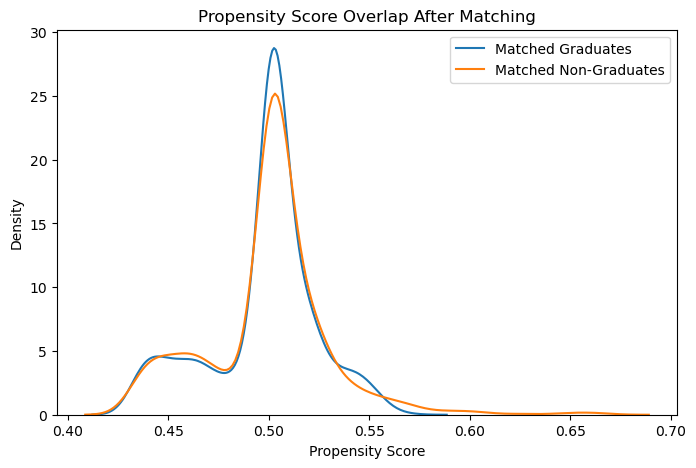

In [141]:
print("Matched pair propensity-score difference summary:")
print(
    matched_sample_loose_status_loosest_match[['match_pair_id', 'match_pscore_diff']]
    .drop_duplicates()['match_pscore_diff']
    .describe()
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(
    matched_sample_loose_status_loosest_match.loc[matched_sample_loose_status_loosest_match['treatment'] == 1, 'pscore'],
    label='Matched Graduates'
)
sns.kdeplot(
    matched_sample_loose_status_loosest_match.loc[matched_sample_loose_status_loosest_match['treatment'] == 0, 'pscore'],
    label='Matched Non-Graduates'
)
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.title('Propensity Score Overlap After Matching')
plt.legend()
plt.show()



In [142]:
#Matching - Loose Status - Better Match

# Covariates for propensity score model - matches 2025 team
psm_vars = [
    'year_TIP',
    'any_sentence_before_start',
    'any_arrest_before_start',
    'num_arrests_before_start',
    'num_sentences_before_start',
    'max_ogs_before_start', #added ogs back in
    'log_earnings_2yr_preTIP', #updated to log earnings
    'job_right_before_tip',
    'age_band'
]

continuous_vars = [
    'year_TIP',
    'num_arrests_before_start',
    'num_sentences_before_start',
    'max_ogs_before_start',
    'log_earnings_2yr_preTIP',
]
categorical_vars = [
    'age_band'
]

matched_sample_loose_status_mid_match = nearest_neighbor_match_within_strata_with_psm(
    df=matching_df,
    psm_vars=psm_vars,
    continuous_vars=continuous_vars,
    categorical_vars=categorical_vars,
    treatment_col='treatment',
    id_col='tip_id',
    caliper=0.1
)

print("matched shape:", matched_sample_loose_status_mid_match.shape)
print("\nMatched pair count:", matched_sample_loose_status_mid_match['match_pair_id'].nunique())

print("\nMatched treatment counts:")
print(matched_sample_loose_status_mid_match['treatment'].value_counts(dropna=False))

if 'pscore' in matched_sample_loose_status_mid_match.columns:
    print("\nMatched propensity score summary:")
    print(matched_sample_loose_status_mid_match.groupby('treatment')['pscore'].describe())

matched shape: (1548, 65)

Matched pair count: 774

Matched treatment counts:
treatment
1    774
0    774
Name: count, dtype: int64

Matched propensity score summary:
           count      mean       std       min      25%       50%       75%  \
treatment                                                                     
0          774.0  0.501018  0.063622  0.379002  0.42462  0.524357  0.546922   
1          774.0  0.497295  0.059788  0.379912  0.42462  0.521536  0.536826   

                max  
treatment            
0          0.642887  
1          0.581399  


In [143]:
smd_table = compute_smd_table(matched_sample_loose_status_mid_match, 'treatment', balance_vars, categorical_vars=['age_band','gender','race'])
smd_table

,variable,SMD
11,age_band_35+,-0.167299
5,earnings_1yr_preTIP,0.092177
10,age_band_25-34,0.088569
0,cohort_2022,0.086791
6,earnings_2yr_preTIP,0.076342
7,log_earnings_1yr_preTIP,0.055987
13,age_band_nan,0.051404
18,race_Other,-0.050882
9,job_right_before_tip,0.040458
8,log_earnings_2yr_preTIP,0.036998


Matched pair propensity-score difference summary:
count    774.000000
mean       0.005512
std        0.010551
min        0.000000
25%        0.000011
50%        0.000875
75%        0.007902
max        0.097836
Name: match_pscore_diff, dtype: float64


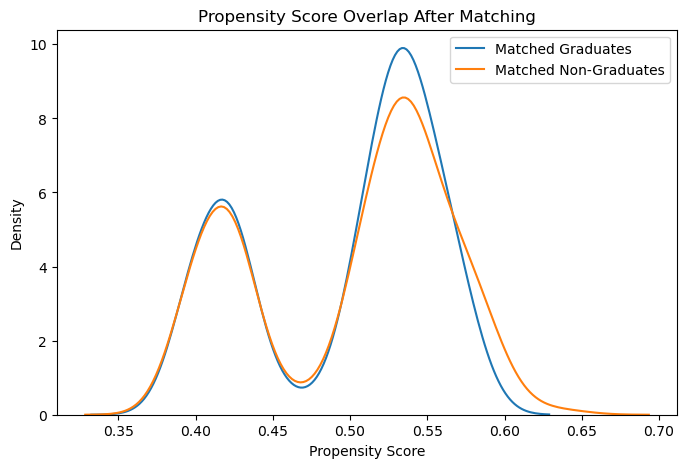

In [144]:
print("Matched pair propensity-score difference summary:")
print(
    matched_sample_loose_status_mid_match[['match_pair_id', 'match_pscore_diff']]
    .drop_duplicates()['match_pscore_diff']
    .describe()
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(
    matched_sample_loose_status_mid_match.loc[matched_sample_loose_status_mid_match['treatment'] == 1, 'pscore'],
    label='Matched Graduates'
)
sns.kdeplot(
    matched_sample_loose_status_mid_match.loc[matched_sample_loose_status_mid_match['treatment'] == 0, 'pscore'],
    label='Matched Non-Graduates'
)
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.title('Propensity Score Overlap After Matching')
plt.legend()
plt.show()



In [145]:
#Matching - Loose Status - Tightest Match

# Covariates for propensity score model
psm_vars = [
    'year_TIP',
    'any_sentence_before_start',
    'any_arrest_before_start',
    'num_arrests_before_start',
    'num_sentences_before_start',
    'max_ogs_before_start', #added ogs back in
    'log_earnings_2yr_preTIP', #updated to log earnings
    'job_right_before_tip',
    'age_band' #added age band
]

continuous_vars = [
    'year_TIP',
    'num_arrests_before_start',
    'num_sentences_before_start',
    'max_ogs_before_start',
    'log_earnings_2yr_preTIP',
]
categorical_vars = [
    'age_band'
]

matched_sample_loose_status_tight_match = nearest_neighbor_match_within_strata_with_psm(
    df=matching_df,
    psm_vars=psm_vars,
    continuous_vars=continuous_vars,
    categorical_vars=categorical_vars,
    treatment_col='treatment',
    id_col='tip_id',
    caliper=0.1,
    exact_match_vars = ['gender','race','cohort_2022'] #exact matching on key variables
)

print("matched shape:", matched_sample_loose_status_tight_match.shape)
print("\nMatched pair count:", matched_sample_loose_status_tight_match['match_pair_id'].nunique())

print("\nMatched treatment counts:")
print(matched_sample_loose_status_tight_match['treatment'].value_counts(dropna=False))

if 'pscore' in matched_sample_loose_status_tight_match.columns:
    print("\nMatched propensity score summary:")
    print(matched_sample_loose_status_tight_match.groupby('treatment')['pscore'].describe())

matched shape: (1526, 65)

Matched pair count: 763

Matched treatment counts:
treatment
1    763
0    763
Name: count, dtype: int64

Matched propensity score summary:
           count      mean       std       min      25%       50%       75%  \
treatment                                                                     
0          763.0  0.501651  0.063508  0.379002  0.42462  0.525622  0.547208   
1          763.0  0.496909  0.059862  0.379912  0.42462  0.521269  0.535873   

                max  
treatment            
0          0.642887  
1          0.581399  


In [146]:
smd_table = compute_smd_table(matched_sample_loose_status_tight_match, 'treatment', balance_vars, categorical_vars=['age_band','gender','race'])
smd_table

,variable,SMD
11,age_band_35+,-0.165251
5,earnings_1yr_preTIP,0.102725
6,earnings_2yr_preTIP,0.087915
10,age_band_25-34,0.079238
13,age_band_nan,0.038077
2,num_sentences_before_start,-0.034552
3,max_ogs_before_start,0.034471
4,num_arrests_before_start,-0.033668
7,log_earnings_1yr_preTIP,0.029231
12,age_band_<=24,0.016644


Matched pair propensity-score difference summary:
count    763.000000
mean       0.007897
std        0.012960
min        0.000000
25%        0.000033
50%        0.002478
75%        0.011275
max        0.097686
Name: match_pscore_diff, dtype: float64


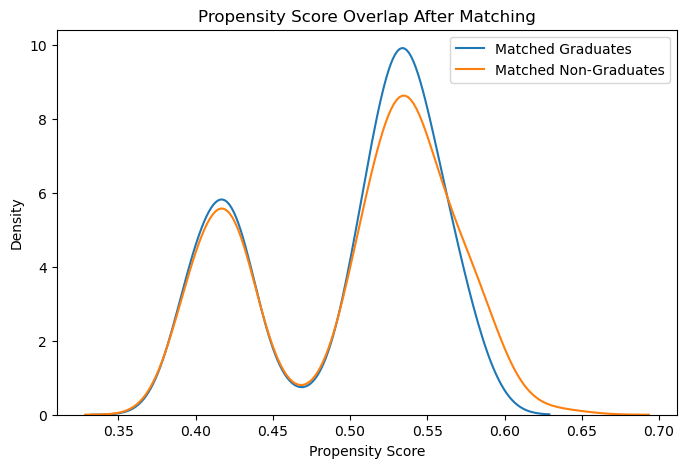

In [147]:
print("Matched pair propensity-score difference summary:")
print(
    matched_sample_loose_status_tight_match[['match_pair_id', 'match_pscore_diff']]
    .drop_duplicates()['match_pscore_diff']
    .describe()
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.kdeplot(
    matched_sample_loose_status_tight_match.loc[matched_sample_loose_status_tight_match['treatment'] == 1, 'pscore'],
    label='Matched Graduates'
)
sns.kdeplot(
    matched_sample_loose_status_tight_match.loc[matched_sample_loose_status_tight_match['treatment'] == 0, 'pscore'],
    label='Matched Non-Graduates'
)
plt.xlabel('Propensity Score')
plt.ylabel('Density')
plt.title('Propensity Score Overlap After Matching')
plt.legend()
plt.show()



In [148]:
#Set up panel data frame

#establish time-variant participated_tip variable
def participated_tip(tip_id, year):
    #filter grad_non_grad data frame to rows where tip_id matches the inputted tip_id AND the year_end_TIP for that tip_id is less than or equal to
    #the year inputted (e.g. - checks if the tip_id has finished TIP by the year inputted into the function)
    if len(all_tip_data[(all_tip_data['tip_id'] == tip_id) & (all_tip_data['year_end_TIP'] <= year)]) > 0:
        #if the filtered dataset has rows > 0, return 1 (participated tip by this time)
        return 1
    else:
        #else 0 (did not finish participation in TIP by this point)
        return 0

#establish time-variant graduated_tip variable
def graduated_tip(tip_id, year):
    #filter grad_non_grad data frame to rows where tip_id matches the inputted tip_id AND the year_end_TIP for that tip_id is less than or equal to
    #the year inputted (e.g. - checks if the tip_id has finished TIP by the year inputted into the function)
    #AND the status of the individuals is a Graduate
    if len(all_tip_data[(all_tip_data['tip_id'] == tip_id) & (all_tip_data['year_end_TIP'] <= year) & (all_tip_data['Strict_Status'] == 'Graduated')]) > 0:
        #if the filtered dataset has rows > 0, return 1 (participated tip by this time AND is a graduate)
        return 1
    else:
        #else 0 (did not finish participation in TIP by this point and/or is not a Graduate)
        return 0

#establish time-variant employment variable
def employed_full_year(tip_id, year):
    # Filter earnings data for the specific person and year, AND only rows where earnings > 0
    earnings = tip_earnings[
        (tip_earnings['tip_id'] == tip_id) & 
        (tip_earnings['year'] == year) & 
        (tip_earnings['adjusted_earnings'] > 0)
    ]
    # if there are no rows in the filtered dataframe, not employed at all that year (0)
    if len(earnings) == 0:
        return 0
    
    #if there are rows in the filtered data frame, check if they were employed for all 4 quarters
    #(rows == 4)
    if earnings['year_quarter_dt'].nunique() == 4:
        return 1
    else:
        return 0

#establish time-variant partial employment variable
def employed_partial_year(tip_id, year):
    # Filter earnings data for the specific person and year, AND only rows where earnings > 0
    earnings = tip_earnings[(tip_earnings['tip_id'] == tip_id) & (tip_earnings['year'] == year) & (tip_earnings['adjusted_earnings'] > 0)]
    # if 0, never employed that year
    if len(earnings) == 0:
        return 0
    else:
        #if the number of unique dates in the filtered dataframe is >0, they were employed at some point, returns 1
        if earnings['year_quarter_dt'].nunique() > 0:
            return 1
        else:
            return 0

#establish time-variant calculation of earnings for the year
def earnings_full_year(tip_id, year):
    #filter earnings data to rows that match the tip_id and inputted year
    earnings = tip_earnings[(tip_earnings['tip_id'] == tip_id) & (tip_earnings['year'] == year)]
    #return the sum of adjusted earnings in the filtered rows. If no rows, report 0 earnings
    return earnings['adjusted_earnings'].sum() if len(earnings) > 0 else 0

#establish time-variant offense count for the year
def offense_count_full_year(tip_id, year):
    #filter offense data to rows that match the tip_id and inputted year
    offenses = tip_sentencing[(tip_sentencing['tip_id'] == tip_id) & (tip_sentencing['year'] == year)]
    #if there are rows, return the number of rows (number of offenses within the year)
    if len(offenses) > 0:
        return len(offenses)
    else:
        return 0

#establish time variant binary offense indicator for the year
def has_offense_full_year(tip_id, year):
    #filter offense data to rows that match the tip_id and year
    offenses = tip_sentencing[(tip_sentencing['tip_id'] == tip_id) & (tip_sentencing['year'] == year) & (tip_sentencing['offense_indicator'] == 1)]
    #if there are rows, return 1 (offense indicator) else 0
    if len(offenses) > 0:
        return 1
    else:
        return 0

def has_offense_by(tip_id, year):
    #filter offense data to rows that match the tip ID and rows that are within or before the year of interest
    offenses = tip_sentencing[(tip_sentencing['tip_id'] == tip_id) & (tip_sentencing['year'] <= year) & (tip_sentencing['offense_indicator'] == 1)]
    #if there are any rows, return 1 (offense by that time indicator) else 0
    if len(offenses) > 0:
        return 1
    else:
        return 0

def has_offense_previous(tip_id, year):
    #filter offense data to rows that match the tip ID and rows that are strictly before the year of interest
    offenses = tip_sentencing[(tip_sentencing['tip_id'] == tip_id) & (tip_sentencing['year'] < year) & (tip_sentencing['offense_indicator'] == 1)]
    #if there are any rows, return 1 (offense by that time indicator) else 0
    if len(offenses) > 0:
        return 1
    else:
        return 0

In [149]:
#create year variable in tip_sentencing that maps to the year on the DOS for each record
tip_sentencing = tip_sentencing.dropna(subset=['DOS'])
tip_sentencing['year'] = tip_sentencing['DOS'].dt.year.astype(int)

#set up all_tip_data as a dict for easier lookup when creating panel data frame
all_tip_data_dict = grad_non_grad_loose.set_index('tip_id').to_dict(orient='index')

In [150]:
#Create the panel data frame
panel_df_loose_status_loosest_match = []

#for each tip id in our matched sample
for tip_id in matched_sample_loose_status_loosest_match.tip_id.unique():
    #for years between 2017 and 2025
    for year in range(2017, 2025):
        panel_df_loose_status_loosest_match.append({
            #pull in time-invariant fields from our data dict
            'tip_id': tip_id,
            'year': year,
            'treatment': all_tip_data_dict[tip_id]['treatment'] if tip_id in all_tip_data_dict else 'Unknown',
            'start_year': all_tip_data_dict[tip_id]['year_TIP'] if tip_id in all_tip_data_dict else 'Unknown',
            'end_year': all_tip_data_dict[tip_id]['year_end_TIP'] if tip_id in all_tip_data_dict else 'Unknown',
            'StartDate' : all_tip_data_dict[tip_id]['StartDate'] if tip_id in all_tip_data_dict else 'Unknown',
            'EndDate' : all_tip_data_dict[tip_id]['EndDate'] if tip_id in all_tip_data_dict else 'Unknown',
            'Loose_Status' : all_tip_data_dict[tip_id]['Loose_Status'] if tip_id in all_tip_data_dict else 'Unknown',
            'age_band': all_tip_data_dict[tip_id]['age_band'] if tip_id in all_tip_data_dict else 'Unknown',
            'cohort_2022' : all_tip_data_dict[tip_id]['cohort_2022'] if tip_id in all_tip_data_dict else 'Unknown',
            'race': tip_demos[tip_id]['race'] if tip_id in tip_demos else 'Unknown',
            'gender': tip_demos[tip_id]['gender'] if tip_id in tip_demos else 'Unknown',
            'census_tract': int(tip_demos[tip_id]['census_tract']) if tip_id in tip_demos and not pd.isnull(tip_demos[tip_id]['census_tract']) else "Unknown",
            #define the time variant variables for each year using the previously established functions
            'participated_tip': participated_tip(tip_id, year),
            'graduated_tip': graduated_tip(tip_id, year),
            'employed_full_year': employed_full_year(tip_id, year),
            'employed_partial_year': employed_partial_year(tip_id, year),
            'earnings_full_year': earnings_full_year(tip_id, year),
            'offense_count_year': offense_count_full_year(tip_id, year),
            'offended_year': has_offense_full_year(tip_id, year),
            'has_offense_by_year': has_offense_by(tip_id, year),
            'has_offense_prior_to_year': has_offense_previous(tip_id, year)
        })

panel_df_loose_status_loosest_match = pd.DataFrame(panel_df_loose_status_loosest_match)

In [151]:
panel_df_loose_status_loosest_match.head()

,tip_id,year,treatment,start_year,end_year,StartDate,EndDate,Loose_Status,age_band,cohort_2022,...,census_tract,participated_tip,graduated_tip,employed_full_year,employed_partial_year,earnings_full_year,offense_count_year,offended_year,has_offense_by_year,has_offense_prior_to_year
0,606,2017,1,2018.0,2018.0,2017-07-05,2017-09-15,Graduated,35+,0.0,...,Unknown,0,0,0,1,116.416289,0,0,0,0
1,606,2018,1,2018.0,2018.0,2017-07-05,2017-09-15,Graduated,35+,0.0,...,Unknown,1,1,0,0,0.000000,0,0,0,0
2,606,2019,1,2018.0,2018.0,2017-07-05,2017-09-15,Graduated,35+,0.0,...,Unknown,1,1,0,0,0.000000,0,0,0,0
3,606,2020,1,2018.0,2018.0,2017-07-05,2017-09-15,Graduated,35+,0.0,...,Unknown,1,1,0,0,0.000000,0,0,0,0
4,606,2021,1,2018.0,2018.0,2017-07-05,2017-09-15,Graduated,35+,0.0,...,Unknown,1,1,0,0,0.000000,0,0,0,0


In [154]:
all_tip_data.groupby(['cohort_2022'])['any_sentence_before_start'].mean()

cohort_2022
0.0    0.416746
1.0    0.250667
Name: any_sentence_before_start, dtype: float64

In [155]:
(
    matched_sample_loose_status_tight_match[
        (matched_sample_loose_status_tight_match['age_band'] != 'Unknown') &
        (matched_sample_loose_status_tight_match['age_band'].notna()) &
        (matched_sample_loose_status_tight_match['age_band'] != 'nan')
    ]
    .groupby(['cohort_2022', 'Loose_Status'])['age_band']
    .value_counts(normalize=True)
    .rename('proportion')
    .reset_index()
)

,cohort_2022,Loose_Status,age_band,proportion
0,0,Graduated,25-34,0.583333
1,0,Graduated,<=24,0.294271
2,0,Graduated,35+,0.122396
3,0,Non Graduated,25-34,0.511335
4,0,Non Graduated,<=24,0.279597
5,0,Non Graduated,35+,0.209068
6,1,Graduated,<=24,0.467949
7,1,Graduated,25-34,0.403846
8,1,Graduated,35+,0.128205
9,1,Non Graduated,<=24,0.462541


In [156]:
(
    all_tip_data[
        (all_tip_data['age_band'] != 'Unknown') &
        (all_tip_data['age_band'].notna())
    ]
    .groupby(['cohort_2022', 'Loose_Status'])['age_band']
    .value_counts(normalize=True)
    .rename('proportion')
    .reset_index()
)

,cohort_2022,Loose_Status,age_band,proportion
0,0.0,Graduated,25-34,0.504386
1,0.0,Graduated,35+,0.247807
2,0.0,Graduated,<=24,0.247807
3,0.0,Non Graduated,25-34,0.414980
4,0.0,Non Graduated,<=24,0.414980
5,0.0,Non Graduated,35+,0.170040
6,0.0,None,25-34,0.500000
7,0.0,None,35+,0.250000
8,0.0,None,<=24,0.250000
9,1.0,Graduated,<=24,0.426513


In [158]:
!jupyter nbconvert --to html Final_Grad_Non_Grad_5.1.2026.ipynb

[NbConvertApp] Converting notebook Final_Grad_Non_Grad_5.1.2026.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 733636 bytes to Final_Grad_Non_Grad_5.1.2026.html
